In [1]:
import pickle
from matplotlib import pyplot as plt
import os

import numpy as np
import scipy as sp
from scipy import signal
import sklearn as sk
from sklearn import neighbors
from scipy.interpolate import interp1d as spline
from sklearn.linear_model import HuberRegressor as hreg

import morph_analyses as m

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:

# load data
with open(m.params.data_dir / "morph_hists.pkl",'rb') as file:
    morph_dict = pickle.load(file)

rare_dists = m.empirical_priors.prior_post(morph_dict['rare'])
freq_dists = m.empirical_priors.prior_post(morph_dict['frequent'])

rare_prior = rare_dists['combined_wallmorph_prior']
freq_prior = freq_dists['combined_wallmorph_prior']

Text(0.5, 0.98, 'Example samples from empirical posteriors')

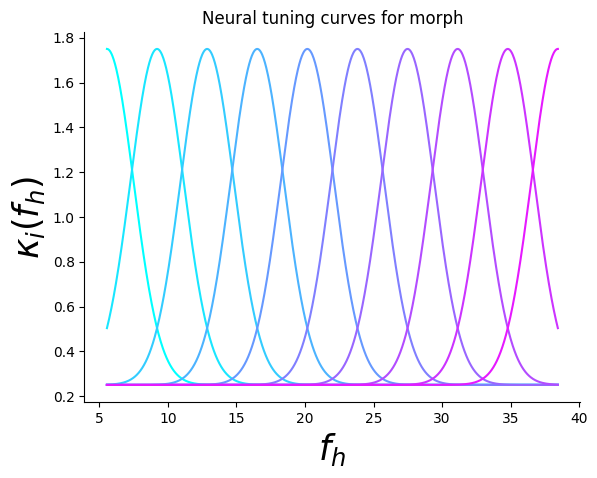

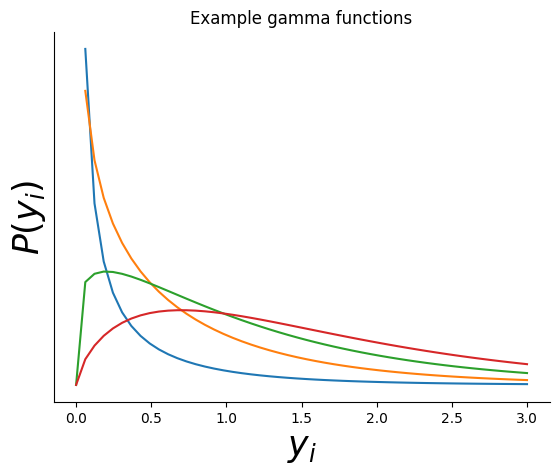

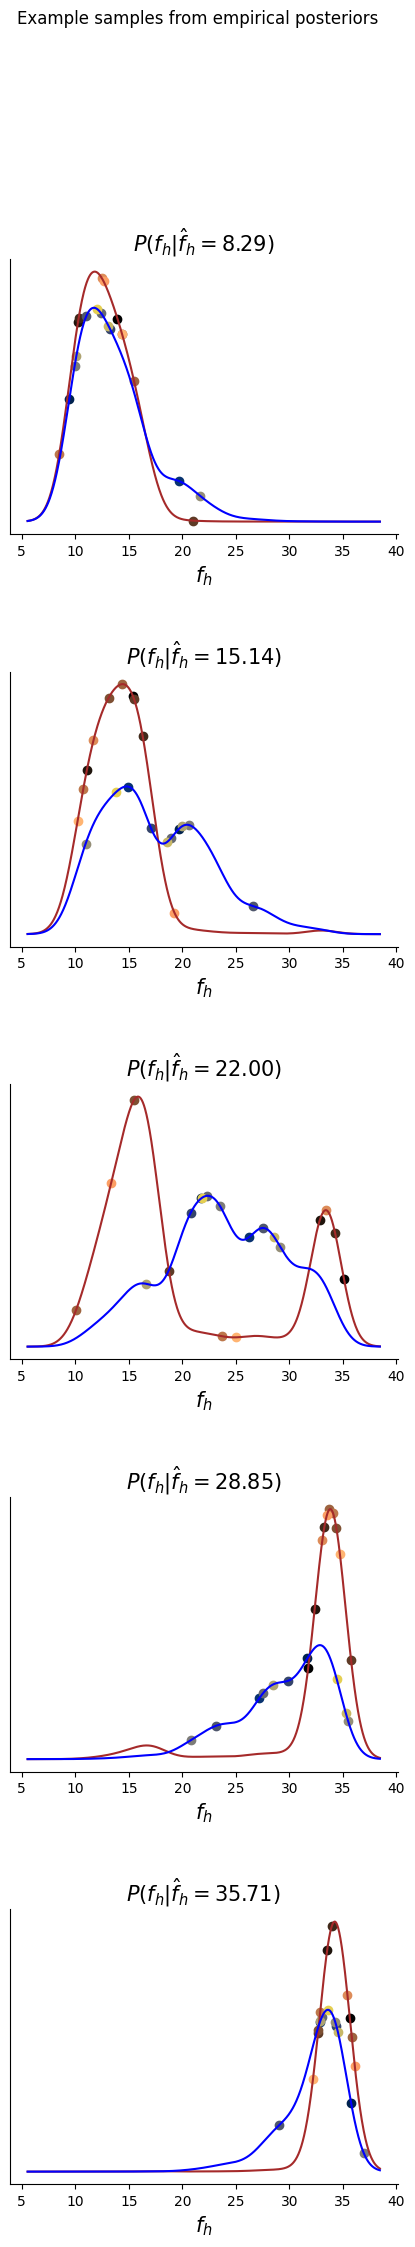

In [6]:
xx = np.linspace(-.1,1.1,num=rare_prior.size)


f,ax = plt.subplots()
mus = np.linspace(-.1,1.1,num = 10)
for i, mu in enumerate(mus.tolist()):
    ax.plot(m.unity_transforms.inv_wallmorphx(xx),1.5*m.utilities.gaussian(mu,.1,xx)+.25,color=plt.cm.cool(float(i)/10.))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("$f_h$",fontsize=25)
ax.set_ylabel("$\kappa_i(f_h)$",fontsize=25)
ax.set_title("Neural tuning curves for morph")


f,ax = plt.subplots()
_x = np.linspace(0,3)
for alpha in np.arange(.2,1.8,.5).tolist(): 
    ax.plot(_x,sp.stats.gamma.pdf(_x,alpha),label="k=%.1f" % alpha )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("$y_i$",fontsize=25)
ax.set_ylabel("$P(y_i)$",fontsize=25)
ax.set_yticks([])
ax.set_title('Example gamma functions')


f,ax = plt.subplots(5,1,figsize=[5,25])
f.subplots_adjust(hspace=.5)
shats= np.array([0, .25,.5,.75,1])
rare_post, xx = m.simulated_sim_mats.calculate_posterior(rare_prior,shats)
freq_post, xx = m.simulated_sim_mats.calculate_posterior(freq_prior,shats)
for j,shat in enumerate(shats.tolist()):
    ax[j].plot(m.unity_transforms.inv_wallmorphx(xx),rare_post[j,:],color='brown')
    ax[j].plot(m.unity_transforms.inv_wallmorphx(xx),freq_post[j,:],color='blue')
    
    rare_post_spline = spline(xx,rare_post[j,:])
    freq_post_spline = spline(xx,freq_post[j,:])
    # sample 10 times
    rare_sampling_spline=m.simulated_sim_mats.make_sampling_spline(xx,rare_post[j,:])
    freq_sampling_spline=m.simulated_sim_mats.make_sampling_spline(xx,freq_post[j,:])
    eps = 5E-3
    for s in range(10):
        sample = rare_sampling_spline(np.random.rand(1))
        ax[j].scatter(m.unity_transforms.inv_wallmorphx(sample),rare_post_spline(sample), c= np.array(plt.cm.copper(s/10.))[np.newaxis,:])
        
        sample = freq_sampling_spline(np.random.rand(1))
        ax[j].scatter(m.unity_transforms.inv_wallmorphx(sample),freq_post_spline(sample), c= np.array(plt.cm.cividis(s/10.))[np.newaxis,:])
    ax[j].set_yticks([])
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].set_title("$P(f_h|\hat{f}_h=%.2f)$" % m.unity_transforms.inv_wallmorphx(shat),fontsize=15)
    ax[j].set_xlabel("$f_h$",fontsize = 15)
    
f.suptitle("Example samples from empirical posteriors")

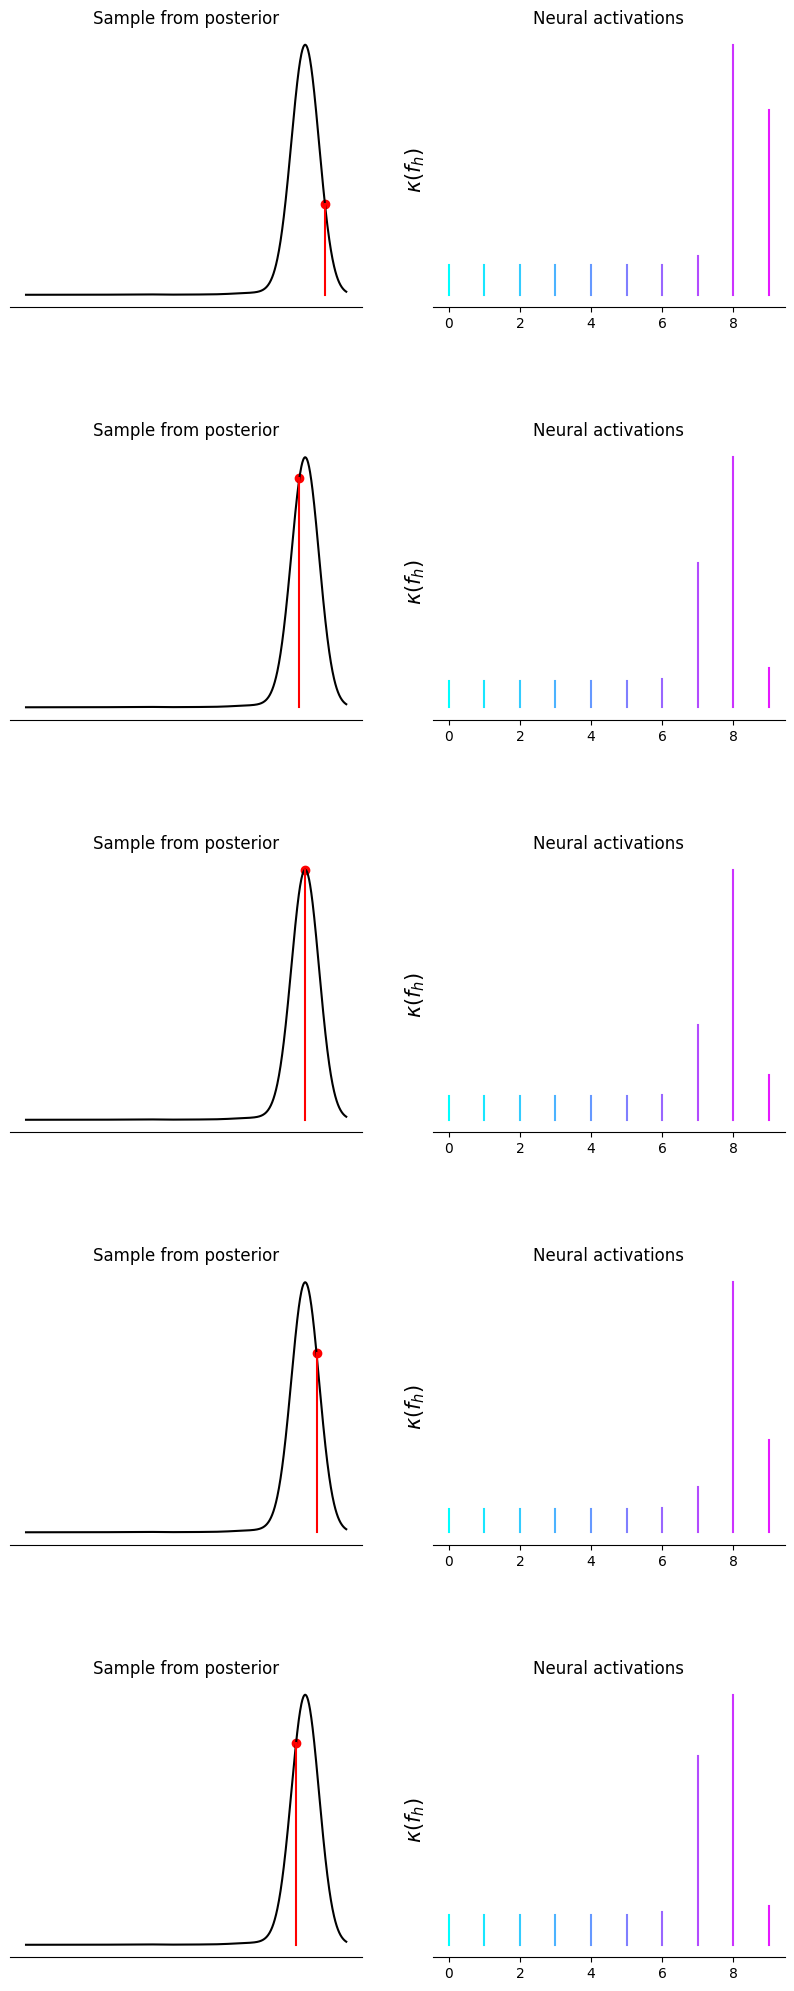

In [7]:
f,ax = plt.subplots(5,2,figsize=[10,25])
f.subplots_adjust(hspace=.5)

# sample 10 times
eps = 5E-3
for s in range(5):
    ax[s,0].plot(m.unity_transforms.inv_wallmorphx(xx),rare_post[-1,:],color='black')
    sample = rare_sampling_spline(np.random.rand(1))[0]
    ax[s,0].scatter(m.unity_transforms.inv_wallmorphx(sample),rare_post_spline(sample), c= 'red')
    ax[s,0].plot(m.unity_transforms.inv_wallmorphx(sample)*np.array([1, 1]),np.array([0, rare_post_spline(sample)]),color='red')
        
    
    ax[s,0].set_yticks([])
    ax[s,0].spines['top'].set_visible(False)
    ax[s,0].spines['right'].set_visible(False)
    ax[s,0].set_xticks([])
    ax[s,0].spines['left'].set_visible(False)
    ax[s,0].set_title('Sample from posterior')
    
    
    
    mus = np.linspace(-.1,1.1,num = 10)
    for i, mu in enumerate(mus.tolist()):
        ax[s,1].plot([i, i],[-.1, m.utilities.gaussian(mu,.1,sample)],color=plt.cm.cool(float(i)/10.))
    ax[s,1].spines['top'].set_visible(False)
    ax[s,1].spines['right'].set_visible(False)
    ax[s,1].spines['left'].set_visible(False)
    ax[s,1].set_yticks([])
    ax[s,1].set_ylabel("$\kappa(f_h)$",fontsize=15)
    ax[s,1].set_title('Neural activations')


In [8]:
x = np.linspace(-.3,1.3,num=1000)[np.newaxis,:]
def single_session_kldiv(_wm,yhat):
    kl_divs=[]
    _x = x.ravel()
    _xmask = (_x>=-.1) & (_x<=1.1)
    HH = 0


    for perm in range(yhat.shape[0]):
        _yh = yhat[perm,:]
        wmsm = m.utilities.gaussian(_wm[:,np.newaxis,np.newaxis],.1,_x[np.newaxis,:,np.newaxis])
        yhsm = m.utilities.gaussian(_yh[:,np.newaxis,np.newaxis],.1,_x[np.newaxis,np.newaxis,:])
        H = np.sum(wmsm*yhsm,axis=0)
        Z=H.sum(axis=1)
        H/=H.sum(axis=1,keepdims=True)

        rare_kl,freq_kl = [],[]
#         print(rare_post.shape,H.shape)
        for row in range(H.shape[1]):
            if (_x[row]>=.1) and (_x[row]<=1.1):
#                 print(rare_post.shape,H.shape)
                rare_kl.append(sp.stats.entropy(rare_post[row,:],H[row,:],base=2))
                freq_kl.append(sp.stats.entropy(freq_post[row,:],H[row,:],base=2))
        rare_kl,freq_kl = np.array(rare_kl),np.array(freq_kl)
        kl_divs.append([rare_kl.mean(),freq_kl.mean()])


        HH+=H
        
    HH/=HH.sum(axis=1,keepdims=True)
    f,ax = plt.subplots()
    ax.imshow(HH.T,cmap='RdPu',extent=[m.unity_transforms.inv_wallmorphx(-.1),
                                       m.unity_transforms.inv_wallmorphx(1.1),
                                       m.unity_transforms.inv_wallmorphx(1.3),
                                       m.unity_transforms.inv_wallmorphx(-.3)])
    
    rare_kl,freq_kl = [],[]
    for row in range(HH.shape[1]):
        if (_x[row]>=.1) and (_x[row]<=1.1):
            rare_kl.append(sp.stats.entropy(rare_post[row,:],HH[row,:],base=2))
            freq_kl.append(sp.stats.entropy(freq_post[row,:],HH[row,:],base=2))
    rare_kl,freq_kl = np.array(rare_kl),np.array(freq_kl)
    
    ax.set_title("diff KL %f" % (np.array(rare_kl).mean()-np.array(freq_kl).mean()))
    
  
    
    return kl_divs,f


# Confirming that this model reproduces the posterior and superficially has the statistics of the real neural data

In [9]:
x = np.linspace(-.3,1.3,num=1000)[np.newaxis,:]
morphs = np.linspace(-.1,1.1,num=100)

rare_simdat_wide,rare_sm, rare_sf_wide = m.simulated_sim_mats.simmat_distribution(
    m.unity_transforms.wallmorphx(morphs),
    rare_prior,
    n_neurons=500,nperms=100,rbf_sigma=.15,alpha=2,beta=0.,xx_lims=[-.3,1.3],n_samps=3)
freq_simdat_wide,freq_sm, freq_sf_wide = m.simulated_sim_mats.simmat_distribution(
    m.unity_transforms.wallmorphx(morphs),
    freq_prior,
    n_neurons=500,nperms=100,rbf_sigma=.15,alpha=2,beta=0.,xx_lims=[-.3,1.3],n_samps=3)

0
0


## Average trial x trial similarity matrices of populations encoding samples from posterior

/tmp/ipykernel_254452/4178871516.py:21: RuntimeWarning: Mean of empty slice
  mu_rare_norm,mu_freq_norm = np.nanmean(mu_rare_norm,axis=0),np.nanmean(mu_freq_norm,axis=0)
/tmp/ipykernel_254452/4178871516.py:22: RuntimeWarning: Mean of empty slice
  mu_rare_bin,mu_freq_bin = np.nanmean(mu_rare_bin,axis=0),np.nanmean(mu_freq_bin,axis=0)


Text(0.5, 0.98, 'Trial x trial similarity matrics')

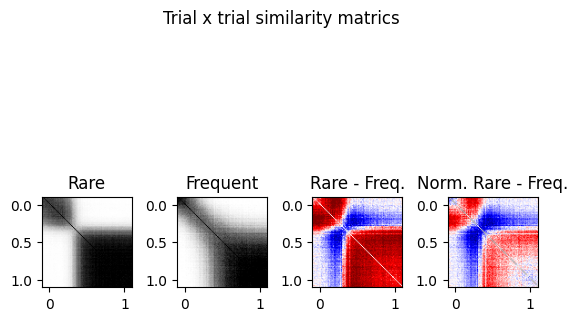

In [11]:
mu_rare_sm,mu_freq_sm = np.nanmean(rare_sm,axis=0),np.nanmean(freq_sm,axis=0)
f,ax = plt.subplots(1,4)
f.subplots_adjust(wspace=.5)
ax[0].imshow(mu_rare_sm,cmap='Greys',vmin = np.percentile(mu_rare_sm.ravel(),10),vmax = np.percentile(mu_rare_sm.ravel(),90),extent=[-.1,1.1,1.1,-.1])
ax[1].imshow(mu_freq_sm,cmap='Greys',vmin = np.percentile(mu_freq_sm.ravel(),10),vmax = np.percentile(mu_freq_sm.ravel(),90),extent=[-.1,1.1,1.1,-.1])


mu_rare_norm, mu_freq_norm = np.zeros(rare_sm.shape),np.zeros(freq_sm.shape)
mu_rare_bin, mu_freq_bin = np.zeros(rare_sm.shape),np.zeros(freq_sm.shape)
for i in range(mu_rare_sm.shape[0]):
    
    _rare = np.copy(rare_sm[i,:,:])
    _rare[np.diag_indices_from(_rare)]=np.nan
    mu_rare_bin[i,:,:] = np.copy(_rare)
    mu_rare_norm[i,:,:]=(_rare - np.nanmean(_rare.ravel()))/np.nanstd(_rare.ravel())
    
    _freq = np.copy(freq_sm[i,:,:])
    _freq[np.diag_indices_from(_freq)]=np.nan
    mu_freq_norm[i,:,:]=(_freq - np.nanmean(_freq.ravel()))/np.nanstd(_freq.ravel())
    mu_freq_bin[i,:,: ]=np.copy(_freq)
mu_rare_norm,mu_freq_norm = np.nanmean(mu_rare_norm,axis=0),np.nanmean(mu_freq_norm,axis=0)
mu_rare_bin,mu_freq_bin = np.nanmean(mu_rare_bin,axis=0),np.nanmean(mu_freq_bin,axis=0)    
ax[2].imshow(mu_rare_sm-mu_freq_sm,cmap='seismic',vmin=-.05,vmax=.05,extent=[-.1,1.1,1.1,-.1])
ax[3].imshow(mu_rare_norm-mu_freq_norm,cmap='seismic',vmin=-1,vmax=1,extent=[-.1,1.1,1.1,-.1])

ax[0].set_title('Rare')
ax[1].set_title('Frequent')
ax[2].set_title('Rare - Freq.')
ax[3].set_title('Norm. Rare - Freq.')
f.suptitle('Trial x trial similarity matrics')


## Binned similarity matrices

Text(0.5, 1.0, 'Norm. Rare-Freq')

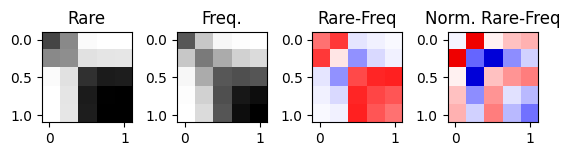

In [12]:
edges = [[-.1,.1,],[.15,.35],[.4,.6],[.65,.85],[.9,1.1]]
rbinmu = np.zeros([5,5])
fbinmu = np.zeros([5,5])
normdiffbin=np.zeros([5,5])
for i,ipair in enumerate(edges):
    imask = (morphs>=ipair[0])&(morphs<=ipair[1])
#     print(imask.shape)
    for j,jpair in enumerate(edges):
        jmask = (morphs>=jpair[0])&(morphs<=jpair[1])
#         print(jmask.shape)
        rbinmu[i,j]=np.nanmean(mu_rare_bin[imask[:,np.newaxis]*jmask[np.newaxis,:]])
        fbinmu[i,j]=np.nanmean(mu_freq_bin[imask[:,np.newaxis]*jmask[np.newaxis,:]])
#         normdiffbin[i,j]=normdiff[imask[:,np.newaxis]*jmask[np.newaxis,:]].mean()
f,ax = plt.subplots(1,4)
f.subplots_adjust(wspace=.5)
ax[0].imshow(rbinmu,cmap='Greys',extent=[-.1,1.1,1.1,-.1])
ax[1].imshow(fbinmu,cmap='Greys',extent=[-.1,1.1,1.1,-.1])
ax[2].imshow(rbinmu-fbinmu,cmap='seismic',vmin=-.1,vmax=.1,extent=[-.1,1.1,1.1,-.1])
ax[3].imshow(sp.stats.zscore(rbinmu,axis=None)-sp.stats.zscore(fbinmu,axis=None),cmap='seismic',vmin=-1.,vmax=1.,extent=[-.1,1.1,1.1,-.1])

ax[0].set_title('Rare')
ax[1].set_title('Freq.')
ax[2].set_title('Rare-Freq')
ax[3].set_title('Norm. Rare-Freq')

## Single simulations, similar to single session trial x trial matrices from real data

(100, 100, 100)


/tmp/ipykernel_254452/1828255126.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f,ax = plt.subplots(1,2,figsize=[3,3])


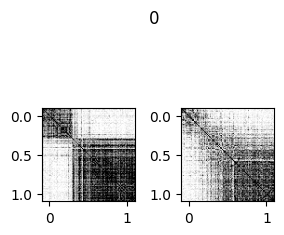

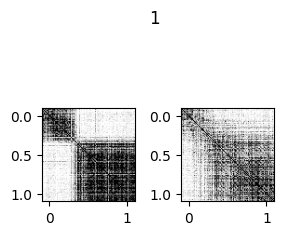

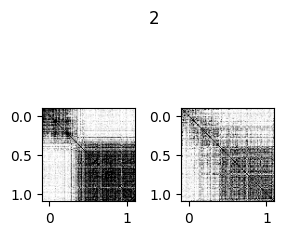

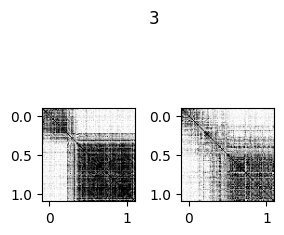

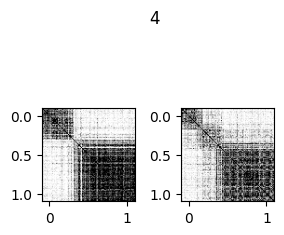

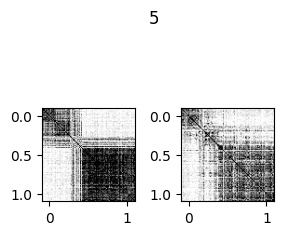

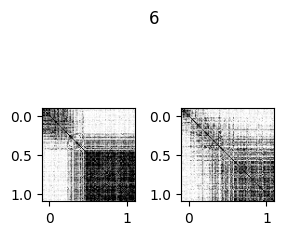

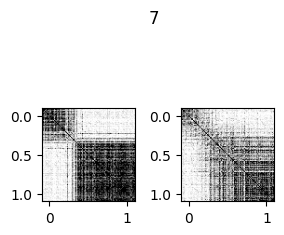

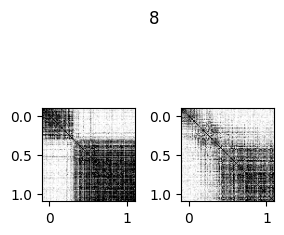

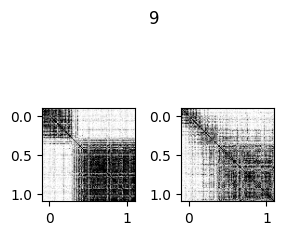

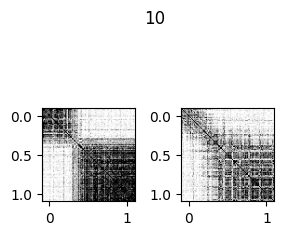

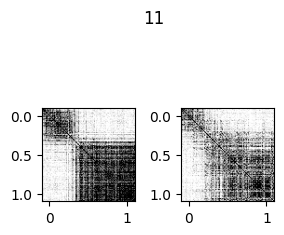

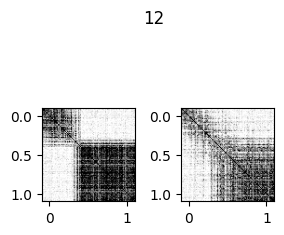

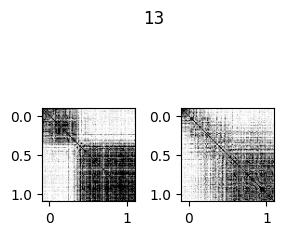

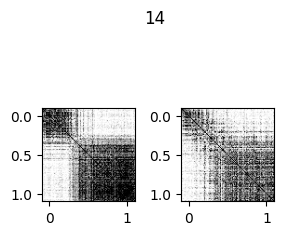

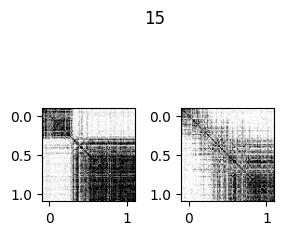

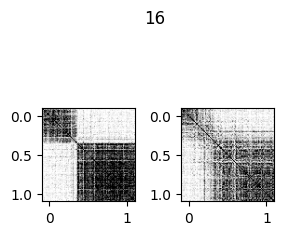

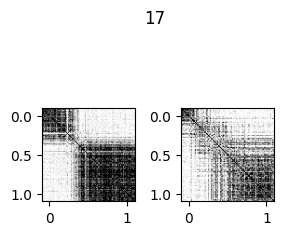

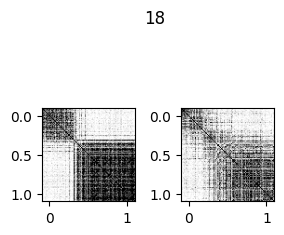

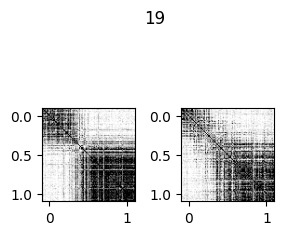

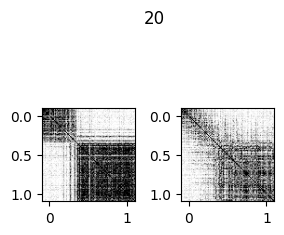

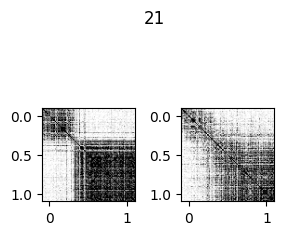

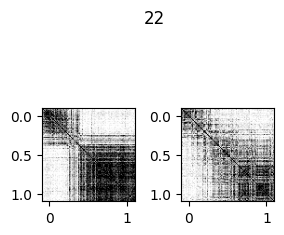

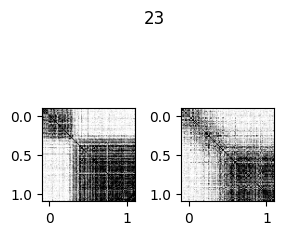

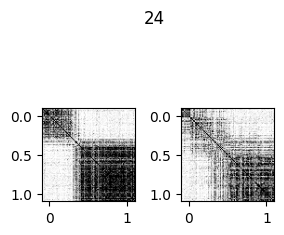

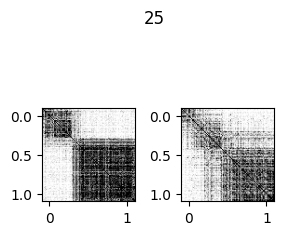

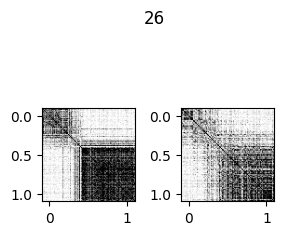

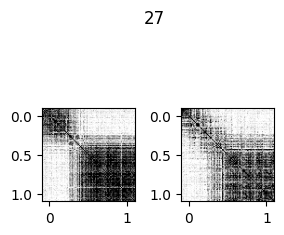

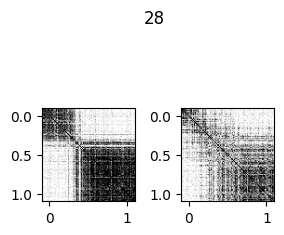

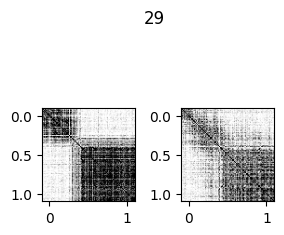

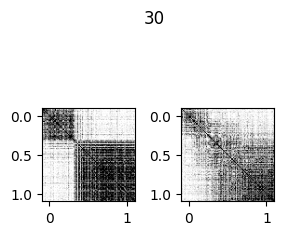

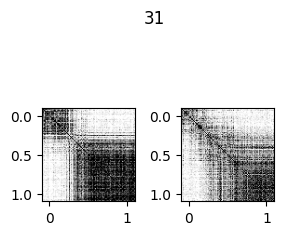

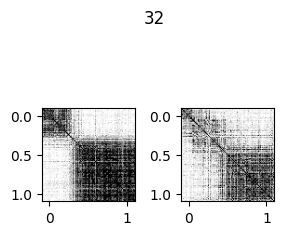

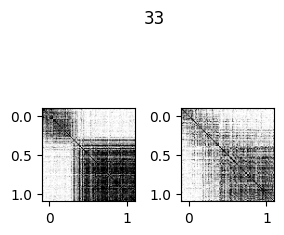

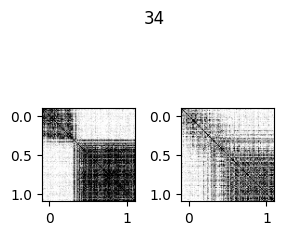

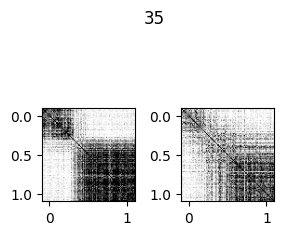

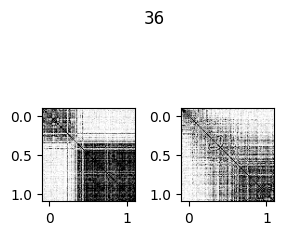

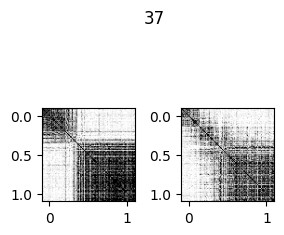

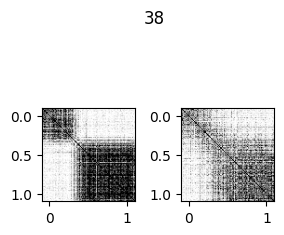

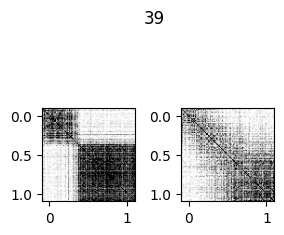

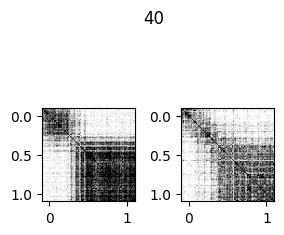

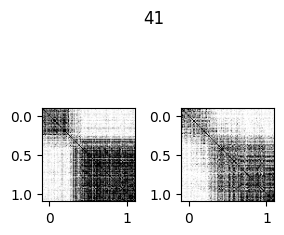

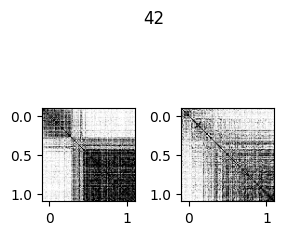

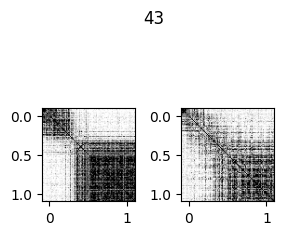

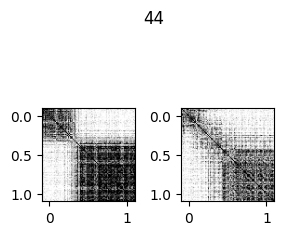

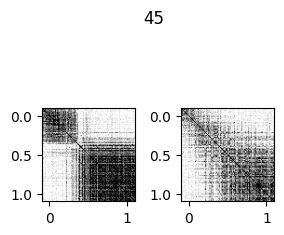

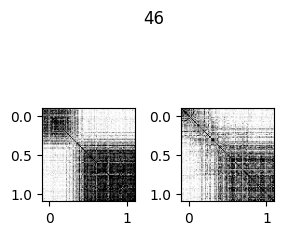

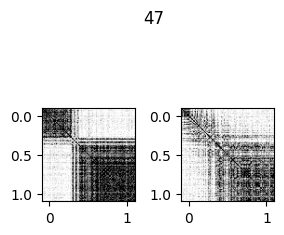

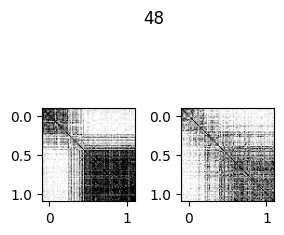

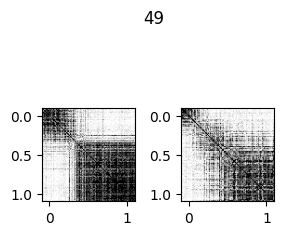

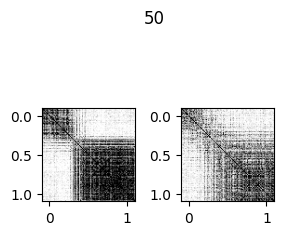

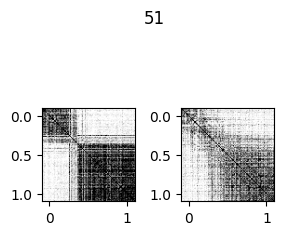

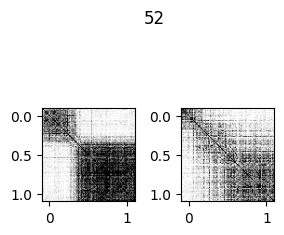

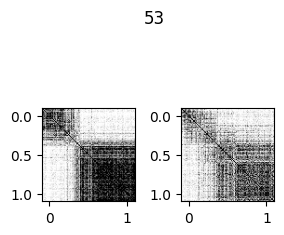

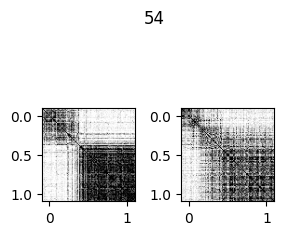

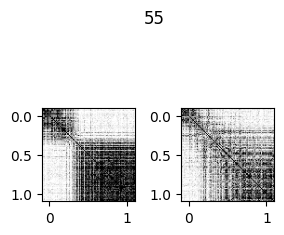

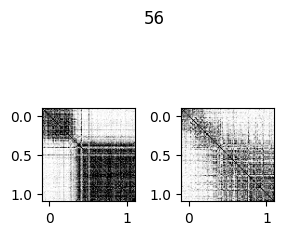

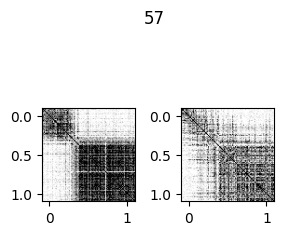

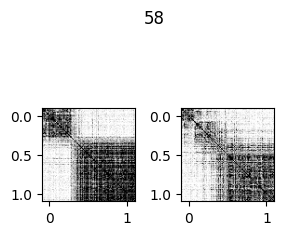

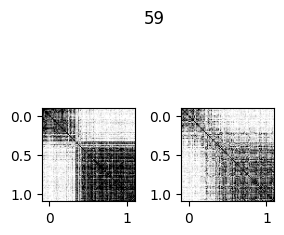

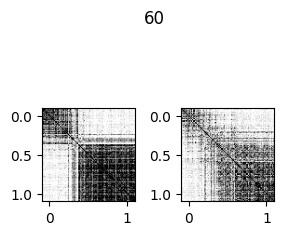

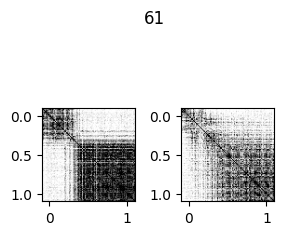

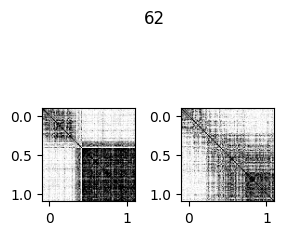

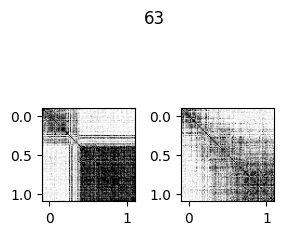

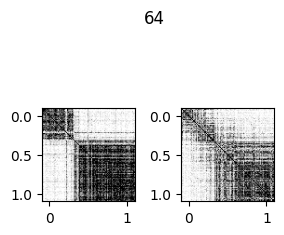

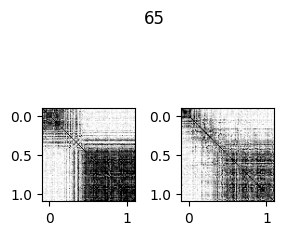

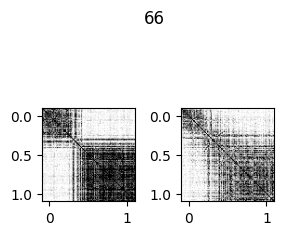

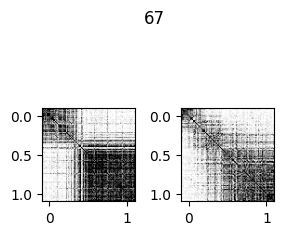

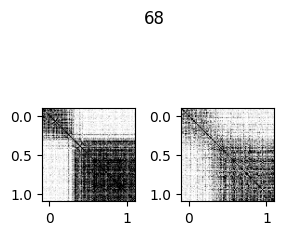

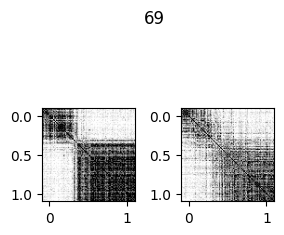

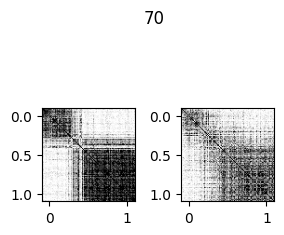

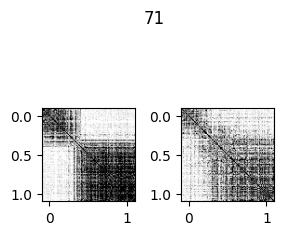

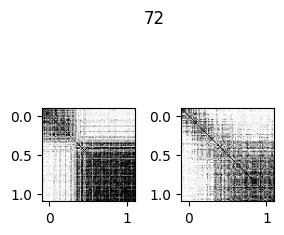

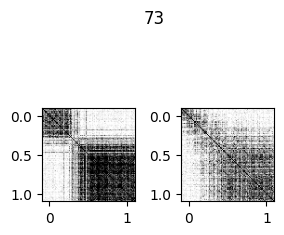

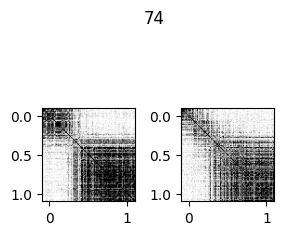

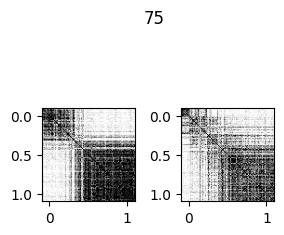

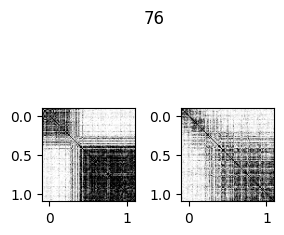

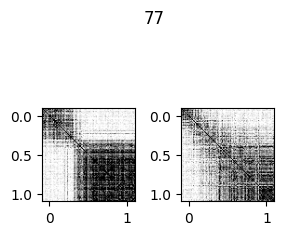

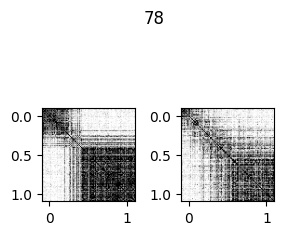

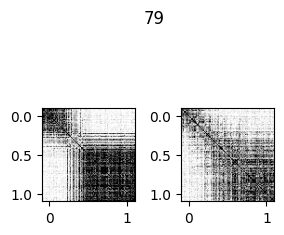

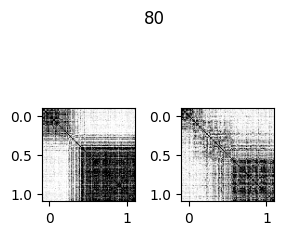

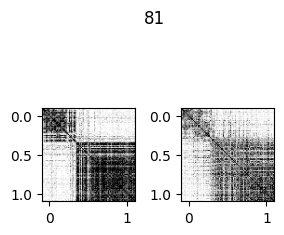

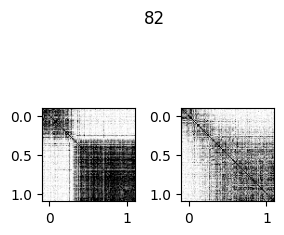

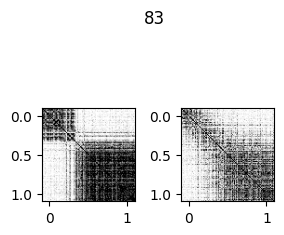

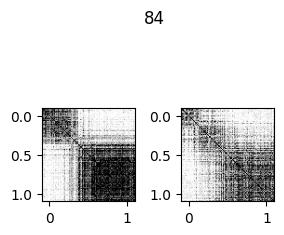

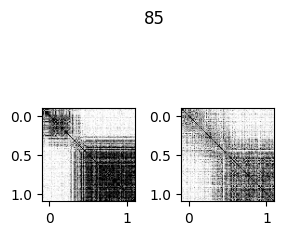

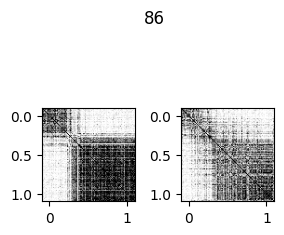

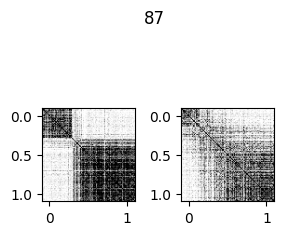

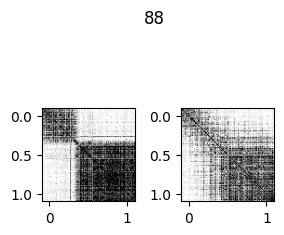

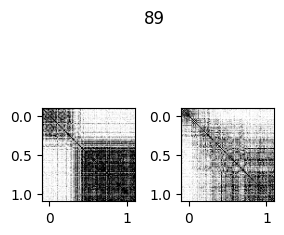

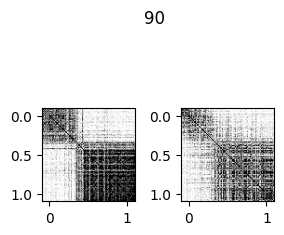

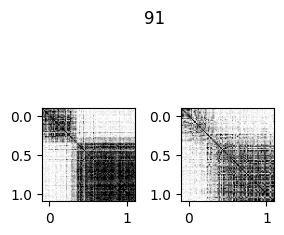

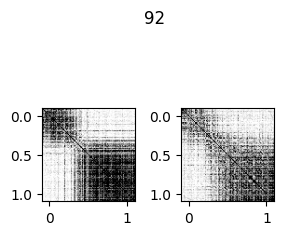

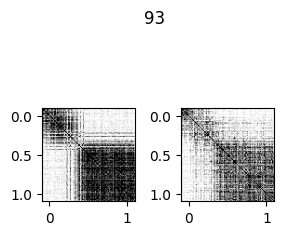

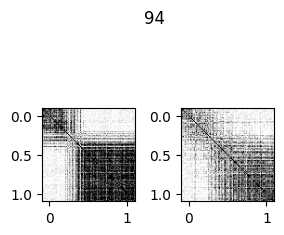

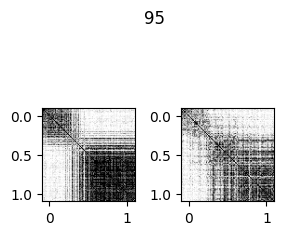

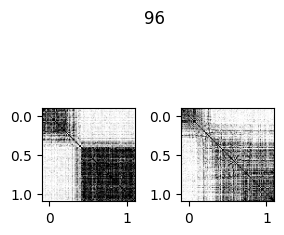

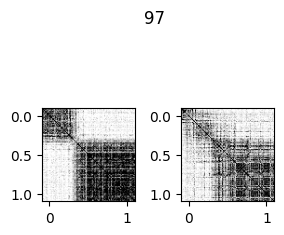

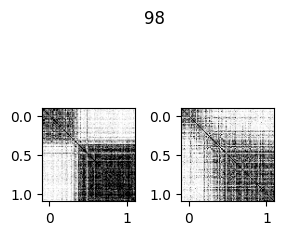

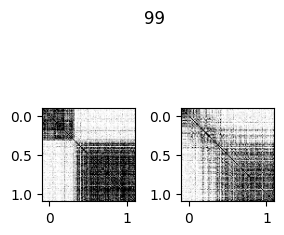

In [13]:
print(rare_sm.shape)
for i in range(rare_sm.shape[0]):
    f,ax = plt.subplots(1,2,figsize=[3,3])
    f.subplots_adjust(wspace=.5)
    ax[0].imshow(rare_sm[i,:,:],cmap='Greys',vmin=np.percentile(rare_sm[i,:,:].ravel(),10),vmax=np.percentile(rare_sm[i,:,:].ravel(),90),extent=[-.1,1.1,1.1,-.1])
    ax[1].imshow(freq_sm[i,:,:],cmap='Greys',vmin=np.percentile(rare_sm[i,:,:].ravel(),10),vmax=np.percentile(rare_sm[i,:,:].ravel(),90),extent=[-.1,1.1,1.1,-.1])
    f.suptitle("%d" % i)
    

## Average posterior reconstructions

(100,) (100, 100)


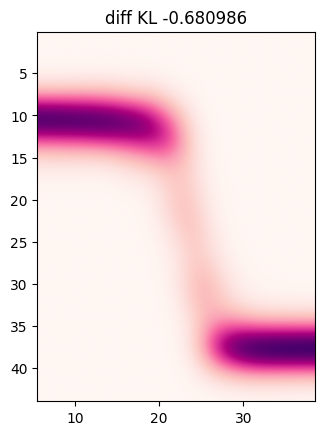

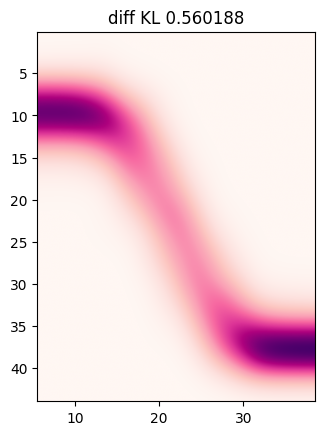

In [14]:
rare_post = rare_dists['wallmorph_posterior']
freq_post = freq_dists['wallmorph_posterior']
mask0 = (morphs>=-.1) & (morphs<=.1)
mask1 = (morphs>=.9) & (morphs<=1.1)
centroid0,centroid1 = np.median(rare_sf_wide[:,mask0],axis=1,keepdims=True),np.median(rare_sf_wide[:,mask1],axis=1,keepdims=True)
rare_yhat = (rare_sf_wide- centroid0)/(centroid1-centroid0)*(1.073-.094) +.094 #(38.051-10.537) + 10.537 #
rare_yhat = np.clip(rare_yhat,-.3,1.3)

centroid0,centroid1 = np.median(freq_sf_wide[:,mask0],axis=1,keepdims=True),np.median(freq_sf_wide[:,mask1],axis=1,keepdims=True)
freq_yhat = (freq_sf_wide- centroid0)/(centroid1-centroid0)*(1.073-.094) +.094 #(38.051-10.537) + 10.537 #
freq_yhat = np.clip(freq_yhat,-.3,1.3)

print(morphs.shape,rare_yhat.shape)
rare_kldivs,f=single_session_kldiv(m.unity_transforms.wallmorphx(morphs),rare_yhat)

freq_kldivs,f=single_session_kldiv(m.unity_transforms.wallmorphx(morphs),freq_yhat)


## KL divergences

(100, 2)


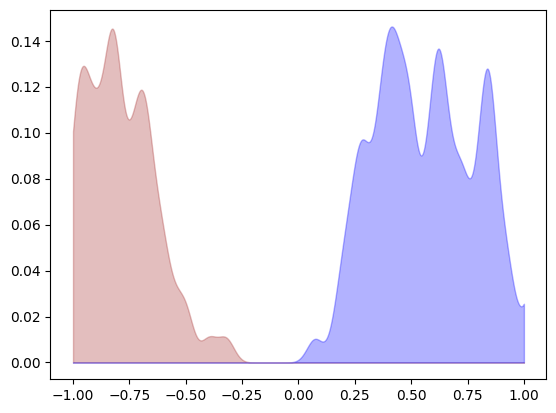

In [15]:
print(np.array(rare_kldivs).shape)
freq_kldivs,rare_kldivs = np.array(freq_kldivs),np.array(rare_kldivs)
rare_kldivs=rare_kldivs[:,0]-rare_kldivs[:,1]
freq_kldivs=freq_kldivs[:,0]-freq_kldivs[:,1]

f,ax = plt.subplots()
kk = np.linspace(-1.,1,num=1000)[np.newaxis,:]
rare_kldivs_sm = m.utilities.gaussian(rare_kldivs[:,np.newaxis],.05,kk).mean(axis=0)
freq_kldivs_sm = m.utilities.gaussian(freq_kldivs[:,np.newaxis],.05,kk).mean(axis=0)
ax.fill_between(kk.ravel(),rare_kldivs_sm,color='brown',alpha=.3)
ax.fill_between(kk.ravel(),freq_kldivs_sm,color='blue',alpha=.3)



In [33]:
# confirm that this gives back a representation of the posterior
_x = np.linspace(-.1,1.1,num=100)
linmorphs = m.unity_transforms.wallmorphx(_x)
rare_post,xx,Z = m.simulated_sim_mats.calculate_posterior(rare_prior,_x,xx_lims = (-.1,1.1),calcZ=True)

morphs = np.linspace(-.1,1.1,num=100)
rare_simdat,rare_sm, rare_sf = m.simulated_sim_mats.simmat_distribution(_x,rare_prior,nperms=100,n_neurons=1000,rbf_sigma=.1,alpha=1.5,beta=0.25,xx_lims=[-.3,1.3])
print(rare_prior.shape)
rare_simdat_wide,rare_sm, rare_sf_wide = m.simulated_sim_mats.simmat_distribution(_x,rare_prior,nperms=100,n_neurons=1000,rbf_sigma=.4,alpha=1.5,beta=0.25,xx_lims=[-.3,1.3])

print(rare_sf_wide.shape) # simulations, trials



0
(1, 1000)
0
(100, 100)


In [34]:

Zspline = spline(_x,Z)
print(rare_simdat.shape)
map_estimate = xx[np.argmax(rare_post,axis=1)]
rare_prior_spline  = spline(xx,rare_prior)
for p in range(100):
    linmodel = hreg().fit(rare_sf[p:p+1,:].T,map_estimate)
    rare_sf[p,:] = linmodel.predict(rare_sf[p:p+1,:].T)
    linmodel= hreg().fit(rare_sf_wide[p:p+1,:].T,map_estimate)
    rare_sf_wide[p,:] = linmodel.predict(rare_sf_wide[p:p+1,:].T)

(100, 100, 1000)


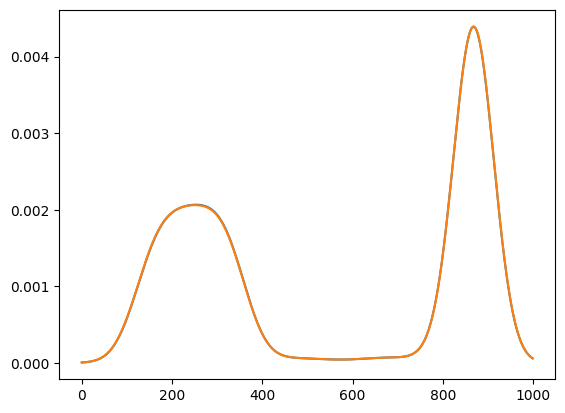

In [36]:

f,ax = plt.subplots()
ax.plot(rare_prior.ravel())
us_prior = rare_post.sum(axis=0)/(m.utilities.gaussian(xx[np.newaxis,:],.3,xx[:,np.newaxis])/Zspline(xx)[np.newaxis,:]).sum(axis=1)
ax.plot(us_prior/us_prior.sum())

Text(0.5, 1.0, '$\\sigma_{rbf}=.4$')

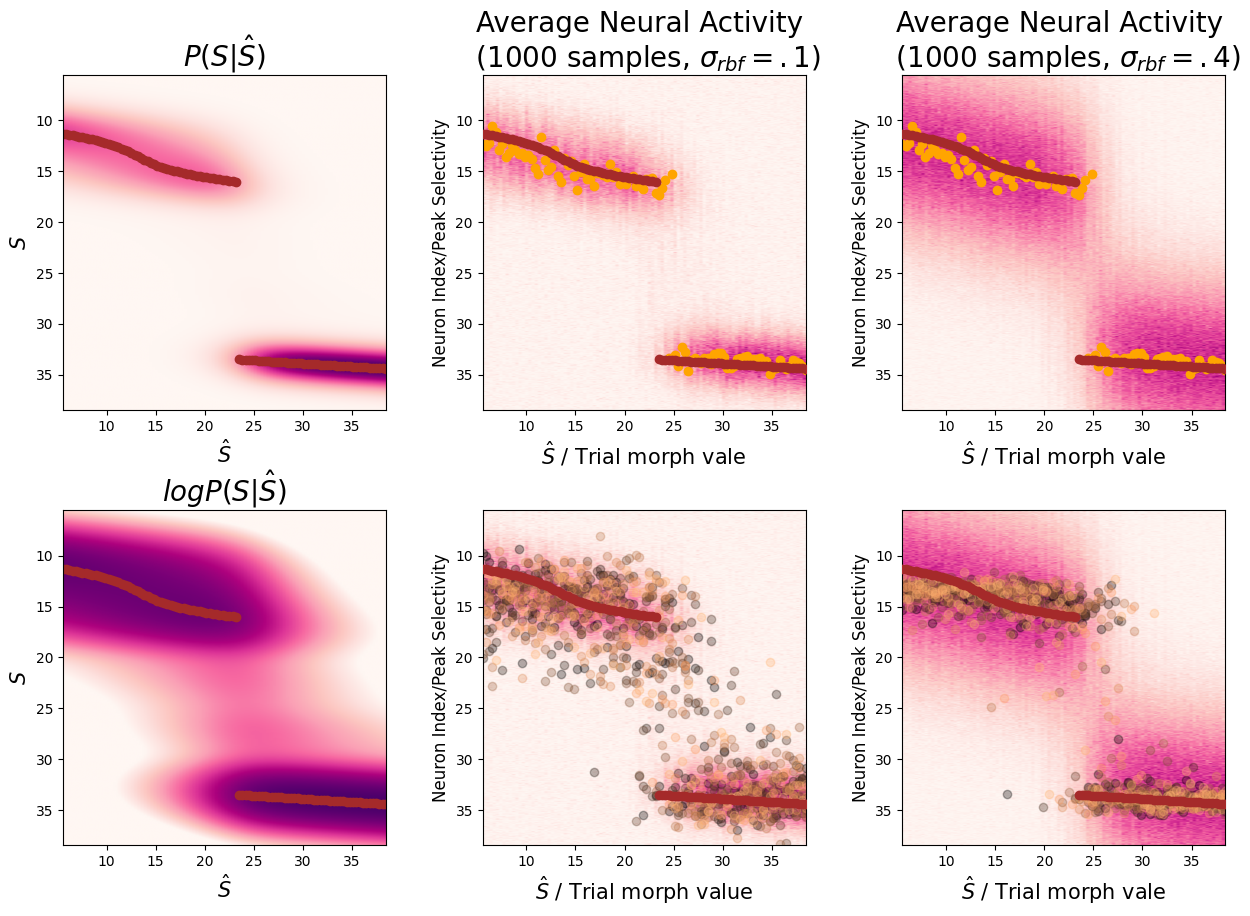

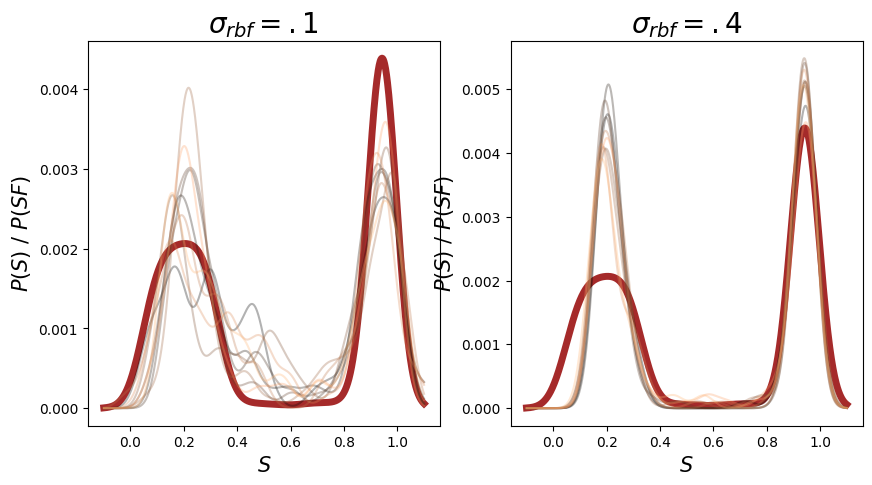

In [43]:
f,ax = plt.subplots(2,3,figsize=[15,10])
f.subplots_adjust(hspace=.3,wspace=.3)
extent = [m.unity_transforms.inv_wallmorphx(-.1),
        m.unity_transforms.inv_wallmorphx(1.1),
        m.unity_transforms.inv_wallmorphx(1.1),
        m.unity_transforms.inv_wallmorphx(-.1)]
ax[0,0].imshow(rare_post.T,cmap = 'RdPu',aspect='auto',vmin=np.percentile(rare_post,20),
               extent = extent)
ax[0,0].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_post,axis=1)]),color='brown')
ax[0,0].set_ylabel("$ S $",fontsize=15)
ax[0,0].set_xlabel("$\hat{S}$",fontsize=15)
ax[0,0].set_title("$P(S|\hat{S})$",fontsize=20)



ax[1,0].imshow(np.log(rare_post.T),cmap = 'RdPu',aspect='auto',vmin=np.percentile(np.log(rare_post),20),
               extent = extent)
ax[1,0].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_post,axis=1)]),color='brown')
ax[1,0].set_ylabel("$ S $",fontsize=15)
ax[1,0].set_xlabel("$\hat{S}$",fontsize=15)
ax[1,0].set_title("$log P(S|\hat{S})$",fontsize=20)

rare_simdat_mean = rare_simdat.mean(axis=0)

ax[0,1].imshow(rare_simdat.mean(axis=0).T,cmap='RdPu',aspect='auto',
               vmin=np.percentile(rare_simdat.mean(axis=0),20),extent = extent)
ax[0,1].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_post,axis=1)]),color='brown',zorder=10)
ax[0,1].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_simdat_mean,axis=1)]),color='orange')
ax[0,1].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[0,1].set_xlabel("$\hat{S}$ / Trial morph vale",fontsize=15)
ax[0,1].set_title("Average Neural Activity \n (1000 samples, $\sigma_{rbf}=.1$)",fontsize=20)

ax[1,1].imshow(rare_simdat.mean(axis=0).T,cmap='RdPu',aspect='auto',
               vmin=np.percentile(rare_simdat.mean(axis=0),20),extent = extent)
ax[1,1].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_post,axis=1)]),
    color='brown',zorder=10)
ax[1,1].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[1,1].set_xlabel("$\hat{S}$ / Trial morph value",fontsize=15)
for j in range(0,100,10):
    ax[1,1].scatter(
        m.unity_transforms.inv_wallmorphx(_x),
        m.unity_transforms.inv_wallmorphx(rare_sf[j,:]),
        zorder=1,color=plt.cm.copper(float(j)/100.),alpha=.3)

rare_simdat_wide_mean = rare_simdat.mean(axis=0)
ax[0,2].imshow(rare_simdat_wide.mean(axis=0).T,cmap='RdPu',aspect='auto',
               vmin=np.percentile(rare_simdat.mean(axis=0),20),extent = extent, zorder=0)
ax[0,2].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_post,axis=1)]),color='brown',zorder=10)
ax[0,2].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_simdat_wide_mean,axis=1)]),color='orange')
ax[0,2].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[0,2].set_xlabel("$\hat{S}$ / Trial morph vale",fontsize=15)
ax[0,2].set_title("Average Neural Activity \n (1000 samples, $\sigma_{rbf}=.4$)",fontsize=20)


ax[1,2].imshow(rare_simdat_wide.mean(axis=0).T,cmap='RdPu',aspect='auto',
               vmin=np.percentile(rare_simdat.mean(axis=0),20),
               extent = extent,zorder=0)
ax[1,2].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(rare_post,axis=1)]),color='brown',zorder=10)
ax[1,2].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[1,2].set_xlabel("$\hat{S}$ / Trial morph vale",fontsize=15)

for j in range(0,100,10):
    ax[1,2].scatter(
        m.unity_transforms.inv_wallmorphx(_x),
        m.unity_transforms.inv_wallmorphx(rare_sf_wide[j,:]),zorder=1,color=plt.cm.copper(float(j)/100.),alpha=.3)
    


f,ax = plt.subplots(1,2,figsize=[10,5])
ax[0].plot(xx,rare_prior.ravel(),color='brown',linewidth=5)
ax[1].plot(xx,rare_prior.ravel(),color='brown',linewidth=5)
edges = np.linspace(-.1,1.1,num=20)
centers = (edges[:-1] + edges[1:])/2.
for j in range(0,100,10):
    _j_rare_sf_bins = np.sum(
        m.utilities.gaussian(rare_sf[j:j+1,:],.05,xx[:,np.newaxis]),axis=1)/(m.utilities.gaussian(xx[np.newaxis,:],.3,xx[:,np.newaxis])/Zspline(xx)[np.newaxis,:]).sum(axis=1)
    ax[0].plot(xx,_j_rare_sf_bins/_j_rare_sf_bins.sum(),color = plt.cm.copper(float(j)/100.),alpha=.3)
    _j_rare_sf_wide_bins = np.sum(m.utilities.gaussian(rare_sf_wide[j:j+1,:],.05,xx[:,np.newaxis]),axis=1)/(m.utilities.gaussian(xx[np.newaxis,:],.3,xx[:,np.newaxis])/Zspline(xx)[np.newaxis,:]).sum(axis=1)
    ax[1].plot(xx,_j_rare_sf_wide_bins/_j_rare_sf_wide_bins.sum(),color = plt.cm.copper(float(j)/100.),alpha=.3)
    
ax[0].set_xlabel("$S$",fontsize=15)
ax[1].set_xlabel("$S$",fontsize=15)

ax[0].set_ylabel("$P(S)$ / $P(SF)$",fontsize=15)
ax[1].set_ylabel("$P(S)$ / $P(SF)$",fontsize=15)


ax[0].set_title("$\sigma_{rbf}=.1$",fontsize = 20)
ax[1].set_title("$\sigma_{rbf}=.4$",fontsize = 20)



In [44]:
freq_post,xx,Z = m.simulated_sim_mats.calculate_posterior(freq_prior,_x,xx_lims = (-.1,1.1),calcZ=True)
freq_simdat,freq_sm, freq_sf = m.simulated_sim_mats.simmat_distribution(_x,freq_prior,n_neurons=1000,nperms=100,rbf_sigma=.1,alpha=1.5,beta=0.25,xx_lims=[-.3,1.3])
freq_simdat_wide,freq_sm, freq_sf_wide = m.simulated_sim_mats.simmat_distribution(_x,freq_prior,n_neurons=1000,nperms=100,rbf_sigma=.4,alpha=1.5,beta=0.25,xx_lims=[-.3,1.3])


Zspline = spline(_x,Z)
map_estimate = xx[np.argmax(freq_post,axis=1)]
for p in range(100):
    linmodel = hreg().fit(freq_sf[p:p+1,:].T,map_estimate)
    freq_sf[p,:] = linmodel.predict(freq_sf[p:p+1,:].T)
    linmodel = hreg().fit(freq_sf_wide[p:p+1,:].T,map_estimate)
    freq_sf_wide[p,:] = linmodel.predict(freq_sf_wide[p:p+1,:].T)
    
    
    

0
0


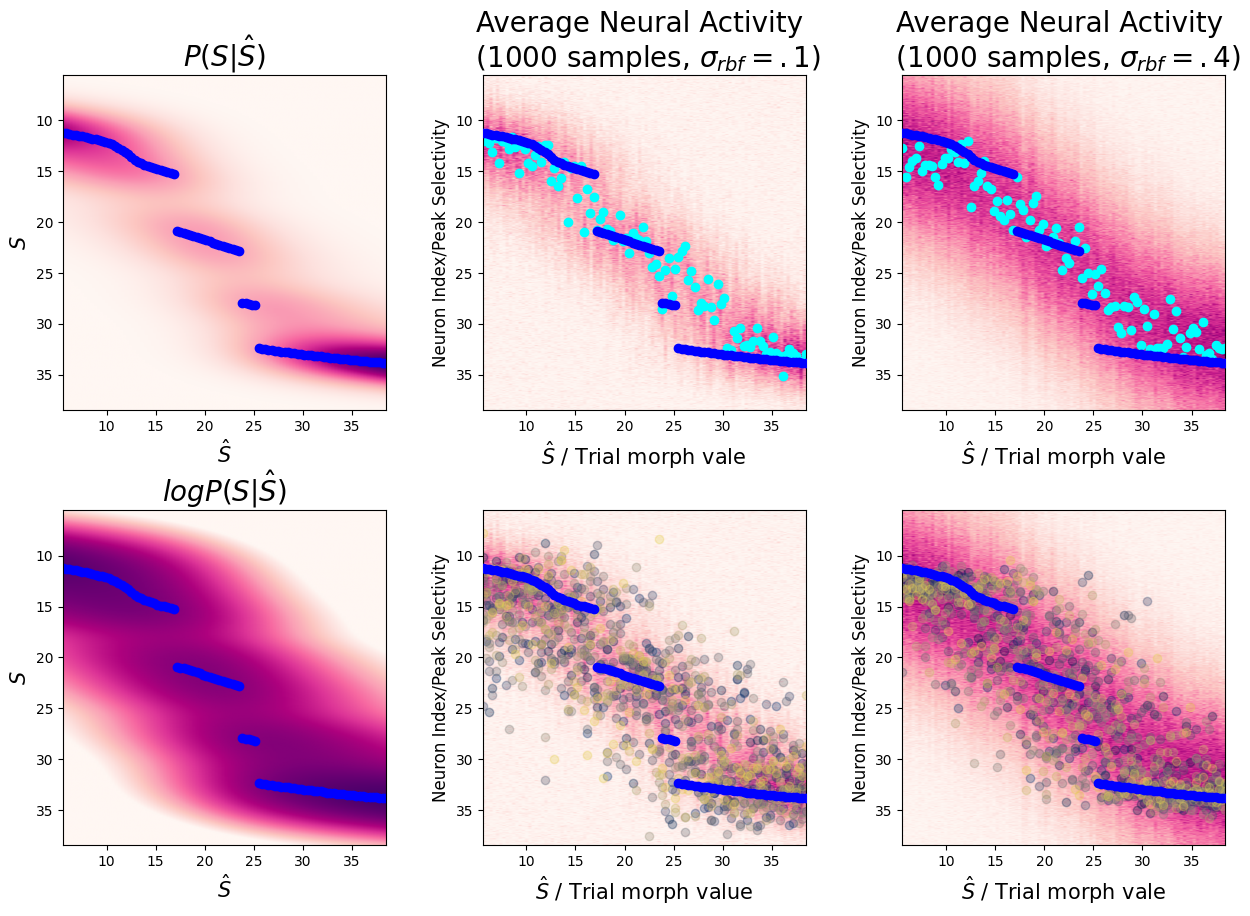

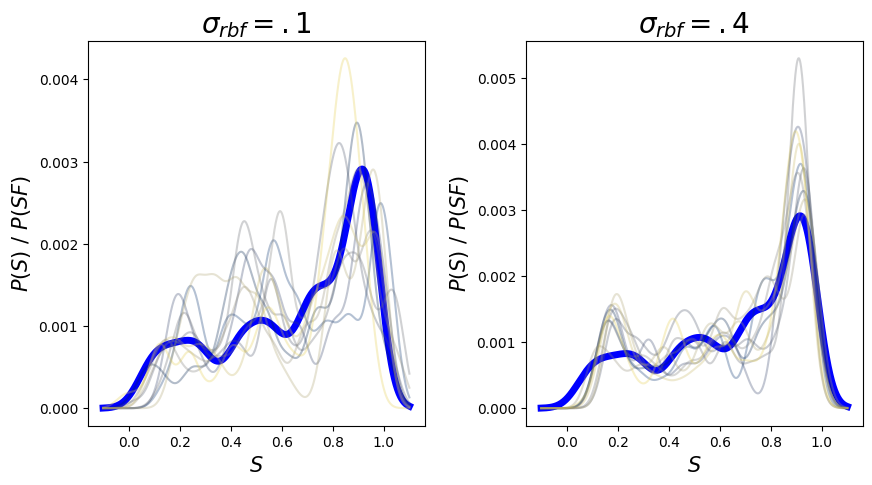

In [48]:
f,ax = plt.subplots(2,3,figsize=[15,10])
f.subplots_adjust(hspace=.3,wspace=.3)
ax[0,0].imshow(freq_post.T,cmap = 'RdPu',aspect='auto',vmin=np.percentile(freq_post,20),
               extent = extent,zorder=0)
ax[0,0].scatter(
    m.unity_transforms.inv_wallmorphx(_x),m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_post,axis=1)]),color='blue')
ax[0,0].set_ylabel("$ S $",fontsize=15)
ax[0,0].set_xlabel("$\hat{S}$",fontsize=15)
ax[0,0].set_title("$P(S|\hat{S})$",fontsize=20)




ax[1,0].imshow(np.log(freq_post.T),cmap = 'RdPu',aspect='auto',vmin=np.percentile(np.log(freq_post),20),
               extent = extent,zorder=0)
ax[1,0].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_post,axis=1)]),color='blue')
ax[1,0].set_ylabel("$ S $",fontsize=15)
ax[1,0].set_xlabel("$\hat{S}$",fontsize=15)
ax[1,0].set_title("$log P(S|\hat{S})$",fontsize=20)



freq_simdat_mean=freq_simdat.mean(axis=0)
ax[0,1].imshow(freq_simdat.mean(axis=0).T,cmap='RdPu',aspect='auto',vmin=np.percentile(freq_simdat.mean(axis=0),20),
               extent = extent)
ax[0,1].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_post,axis=1)]),color='blue',zorder=10)
ax[0,1].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_simdat_mean,axis=1)]),color='cyan')
ax[0,1].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[0,1].set_xlabel("$\hat{S}$ / Trial morph vale",fontsize=15)
ax[0,1].set_title("Average Neural Activity \n (1000 samples, $\sigma_{rbf}=.1$)",fontsize=20)

ax[1,1].imshow(freq_simdat.mean(axis=0).T,cmap='RdPu',aspect='auto',vmin=np.percentile(freq_simdat.mean(axis=0),20),
               extent = extent)
ax[1,1].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_post,axis=1)]),color='blue',zorder=10)
ax[1,1].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[1,1].set_xlabel("$\hat{S}$ / Trial morph value",fontsize=15)
for j in range(0,100,10):
    ax[1,1].scatter(
        m.unity_transforms.inv_wallmorphx(_x),
        m.unity_transforms.inv_wallmorphx(freq_sf[j,:]),
        zorder=1,color=plt.cm.cividis(float(j)/100.),alpha=.3)

freq_simdat_wide_mean=freq_simdat_wide.mean(axis=0)
ax[0,2].imshow(freq_simdat_wide.mean(axis=0).T,cmap='RdPu',aspect='auto',vmin=np.percentile(freq_simdat.mean(axis=0),20),
               extent=extent,zorder=0)
ax[0,2].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_post,axis=1)]),
    color='blue',zorder=10)
ax[0,2].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_simdat_wide_mean,axis=1)]),
    color='cyan')
ax[0,2].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[0,2].set_xlabel("$\hat{S}$ / Trial morph vale",fontsize=15)
ax[0,2].set_title("Average Neural Activity \n (1000 samples, $\sigma_{rbf}=.4$)",fontsize=20)


ax[1,2].imshow(freq_simdat_wide.mean(axis=0).T,cmap='RdPu',aspect='auto',vmin=np.percentile(freq_simdat.mean(axis=0),20),
               extent=extent,zorder=0)
ax[1,2].scatter(
    m.unity_transforms.inv_wallmorphx(_x),
    m.unity_transforms.inv_wallmorphx(xx[np.argmax(freq_post,axis=1)]),color='blue',zorder=10)
ax[1,2].set_ylabel("Neuron Index/Peak Selectivity",fontsize=12)
ax[1,2].set_xlabel("$\hat{S}$ / Trial morph vale",fontsize=15)
# ax[3].scatter(linmorphs,rare_sf_wide.mean(axis=0))
for j in range(0,100,10):
    ax[1,2].scatter(
        m.unity_transforms.inv_wallmorphx(_x),
        m.unity_transforms.inv_wallmorphx(freq_sf_wide[j,:]),zorder=1,color=plt.cm.cividis(float(j)/100.),alpha=.3)
    
f,ax = plt.subplots(1,2,figsize=[10,5])
ax[0].plot(xx,freq_prior.ravel(),color='blue',linewidth=5)
ax[1].plot(xx,freq_prior.ravel(),color='blue',linewidth=5)
edges = np.linspace(-.1,1.1,num=20)
centers = (edges[:-1] + edges[1:])/2.
for j in range(0,100,10):
    _j_freq_sf_bins = np.mean(m.utilities.gaussian(freq_sf[j:j+1,:],.05,xx[:,np.newaxis]),axis=1)/(m.utilities.gaussian(xx[np.newaxis,:],.3,xx[:,np.newaxis])/Zspline(xx)[np.newaxis,:]).sum(axis=1)
    ax[0].plot(xx,_j_freq_sf_bins/_j_freq_sf_bins.sum(),color = plt.cm.cividis(float(j)/100.),alpha=.3)
    _j_freq_sf_wide_bins = np.mean(m.utilities.gaussian(freq_sf_wide[j:j+1,:],.05,xx[:,np.newaxis]),axis=1)/(m.utilities.gaussian(xx[np.newaxis,:],.3,xx[:,np.newaxis])/Zspline(xx)[np.newaxis,:]).sum(axis=1)
    ax[1].plot(xx,_j_freq_sf_wide_bins/_j_freq_sf_wide_bins.sum(),color = plt.cm.cividis(float(j)/100.),alpha=.3)
    
ax[0].set_xlabel("$S$",fontsize=15)
ax[1].set_xlabel("$S$",fontsize=15)

ax[0].set_ylabel("$P(S)$ / $P(SF)$",fontsize=15)
ax[1].set_ylabel("$P(S)$ / $P(SF)$",fontsize=15)


ax[0].set_title("$\sigma_{rbf}=.1$",fontsize = 20)
ax[1].set_title("$\sigma_{rbf}=.4$",fontsize = 20)



f.subplots_adjust(wspace=.3)
